In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

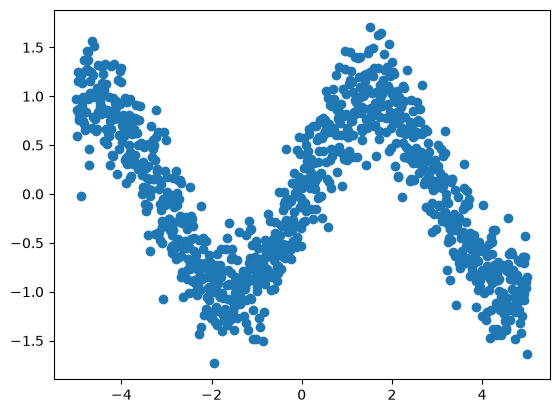

In [2]:
n = 1000
x_data = torch.linspace(-5, 5, n)
nu, scale = torch.tensor(0.0), torch.tensor(0.3)
noise = torch.normal(nu, scale, size=x_data.size())
y_data = torch.sin(x_data) + noise
plt.scatter(x_data, y_data)

Step 0, Loss: 1.1680151224136353
Step 1, Loss: 1.1434904336929321
Step 2, Loss: 1.1270859241485596
Step 3, Loss: 1.1209734678268433
Step 4, Loss: 1.1295654773712158
Step 5, Loss: 1.1575392484664917
Step 6, Loss: 1.2124360799789429
Step 7, Loss: 1.3034775257110596
Step 8, Loss: 1.444029688835144
Step 9, Loss: 1.6512012481689453
Step 10, Loss: 1.9480600357055664
Step 11, Loss: 2.3637287616729736
Step 12, Loss: 2.933759927749634
Step 13, Loss: 3.699141025543213
Step 14, Loss: 4.69877290725708
Step 15, Loss: 5.962783336639404
Step 16, Loss: 7.483695030212402
Step 17, Loss: 9.203042984008789
Step 18, Loss: 10.958490371704102
Step 19, Loss: 12.511134147644043
Step 20, Loss: 13.535439491271973
Step 21, Loss: 13.790711402893066
Step 22, Loss: 13.169873237609863
Step 23, Loss: 11.847783088684082
Step 24, Loss: 10.126582145690918
Step 25, Loss: 8.349838256835938
Step 26, Loss: 6.735642910003662
Step 27, Loss: 5.379117488861084
Step 28, Loss: 4.2843427658081055
Step 29, Loss: 3.4147398471832275
S

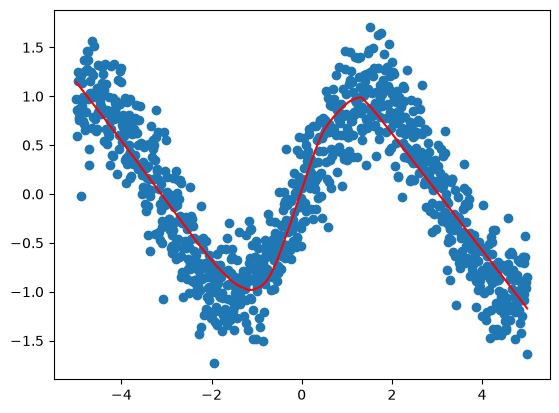

In [3]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.linear1 = nn.Linear(1, 128)
        self.linear2 = nn.Linear(128, 1)
        self.relu = nn.ReLU()
        self.optimizer = torch.optim.SGD(self.parameters(), lr=1e-2)
    
    def forward(self, _input):
        hidden = self.linear1(_input)
        hidden = self.relu(hidden)
        output = self.linear2(hidden)
        return output

    def learn(self, x_data, y_data, step_n=200):
        for step in range(step_n):
            y_pred = self.forward(x_data)
            loss = torch.mean((y_data - y_pred) ** 2)
            print(f'Step {step}, Loss: {loss.item()}')
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

network = Network()

network.learn(x_data.reshape(-1,1), y_data.reshape(-1,1))
y_pred = network(x_data.reshape(-1,1))

plt.scatter(x_data, y_data)
plt.plot(x_data, y_pred.detach(), color='red')
plt.show()

In [6]:
x_data.reshape(-1,1).shape

torch.Size([1000, 1])